In [2]:
!pip install -q kaggle tensorflow matplotlib scikit-learn pandas seaborn

In [3]:
!pip install -q ultralytics==8.0.160 matplotlib seaborn opencv-python-headless scikit-learn pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 609.3/609.3 kB 33.3 MB/s eta 0:00:00


In [4]:
pip install --upgrade ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.160
    Uninstalling ultralytics-8.0.160:
      Successfully uninstalled ultralytics-8.0.160


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import os

acne_yolo_folder_path = '/content/drive/MyDrive/acne-yolo'
print("Files in the acne-yolo folder:")
for filename in os.listdir(acne_yolo_folder_path):
    print(filename)

Files in the acne-yolo folder:
README.roboflow.txt
README.dataset.txt
valid
train
test
data.yaml.bak
data.yaml


In [7]:
DATA_DIR = '/content/drive/MyDrive/acne-yolo'
print("DATA_DIR:", DATA_DIR)

DATA_DIR: /content/drive/MyDrive/acne-yolo


In [8]:
import os, yaml, glob, pprint

yaml_path = os.path.join(DATA_DIR, 'data.yaml')
print("data.yaml exists:", os.path.exists(yaml_path))
if os.path.exists(yaml_path):
    with open(yaml_path) as f:
        info = yaml.safe_load(f)
    pprint.pprint(info)
else:
    # show counts if no yaml
    print("No data.yaml found. Showing image/label counts:")
    for split in ['train','valid','test','val']:
        img_dir = os.path.join(DATA_DIR, 'images', split)
        lbl_dir = os.path.join(DATA_DIR, 'labels', split)
        print(f"{split}: images:", len(glob.glob(img_dir+'/*')) , ", labels:", len(glob.glob(lbl_dir+'/*')))


data.yaml exists: True
{'names': ['blackheads',
           'dark spot',
           'nodules',
           'papules',
           'pustules',
           'whiteheads'],
 'nc': 6,
 'test': 'test',
 'train': 'train',
 'val': 'valid'}


In [9]:
import os, yaml, shutil

yaml_path = '/content/drive/MyDrive/acne-yolo/data.yaml'
#backing up
shutil.copy(yaml_path, yaml_path + '.bak')
print("Backup created at:", yaml_path + '.bak')

#NEW FIXED YAML
data_fixed = {
    'train': 'train',
    'val': 'valid',
    'test': 'test',
    'nc': 6,
    'names': [
        'blackheads',
        'dark spot',
        'nodules',
        'papules',
        'pustules',
        'whiteheads'
    ]
}

with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_fixed, f)

print("NEW data.yaml written successfully:")
print(data_fixed)


Backup created at: /content/drive/MyDrive/acne-yolo/data.yaml.bak
NEW data.yaml written successfully:
{'train': 'train', 'val': 'valid', 'test': 'test', 'nc': 6, 'names': ['blackheads', 'dark spot', 'nodules', 'papules', 'pustules', 'whiteheads']}


In [10]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='/content/drive/MyDrive/acne-yolo/data.yaml',
            epochs=40,
            imgsz=640,
            batch=16,
            name='acne_yolov8n_run1')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/acne-yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, io

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7949605ecfb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/1 /content/drive/MyDrive/acne-yolo/test/images/1.jpg: 512x640 2 papuless, 2 pustuless, 59.2ms
Speed: 3.1ms preprocess, 59.2ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)


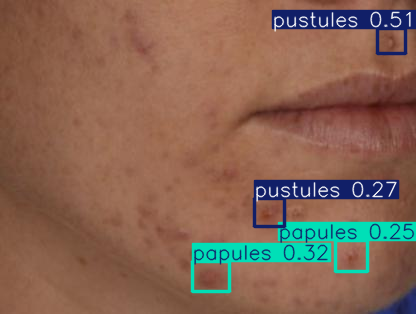

'results_1.jpg'

In [11]:
model = YOLO('runs/detect/acne_yolov8n_run1/weights/best.pt')

# Predict on new images
results = model('/content/drive/MyDrive/acne-yolo/test/images/1.jpg')
results[0].show()
results[0].save()
#expected result should be
#4 0.15144230769230768 0.5379746835443038 0.052884615384615384 0.0379746835443038
#4 0.23076923076923078 0.5537974683544303 0.057692307692307696 0.07911392405063292
#4 0.31009615384615385 0.5854430379746836 0.0625 0.06962025316455696
#4 0.15625 0.6170886075949367 0.06009615384615385 0.06962025316455696
#1 0.7379807692307693 0.11708860759493671 0.052884615384615384 0.06645569620253164
#1 0.8028846153846154 0.13924050632911392 0.057692307692307696 0.056962025316455694
#1 0.6778846153846154 0.16139240506329114 0.04326923076923077 0.04746835443037975



=== Running Ultralytics built-in validation (model.val) on test split ===
Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 0.0±0.0 MB/s, size: 15.1 KB)
val: Scanning /content/drive/MyDrive/acne-yolo/test/labels... 89 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 92/92 0.6it/s 2:23
val: New cache created: /content/drive/MyDrive/acne-yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.2it/s 5.0s
                   all         92        884      0.192      0.203      0.136      0.048
            blackheads          9         33          0          0    0.00704    0.00167
             dark spot         48        382      0.247      0.348      0.209     0.0667
               nodules         17         46      0.154      0.087     0.0718   

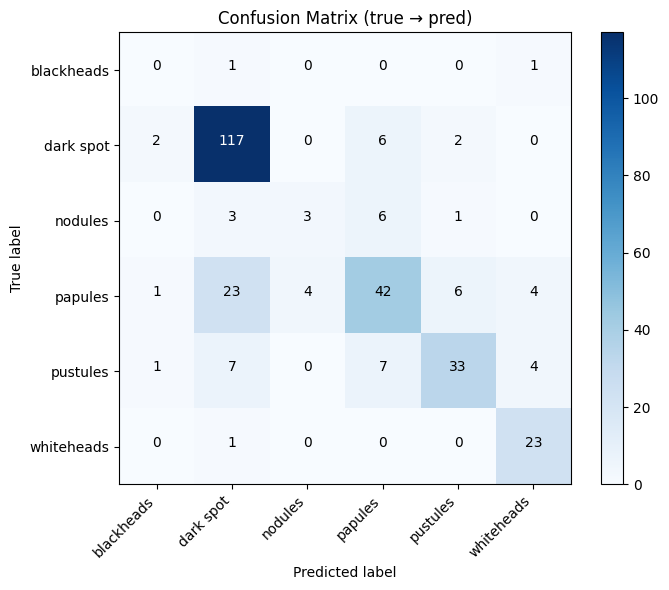


Saved custom metrics to: /content/drive/MyDrive/acne-yolo/custom_detection_metrics.json


In [12]:
# ---------- EVALUATION BLOCK (append after your current code) ----------
import os
import json
from pathlib import Path
from collections import defaultdict
import numpy as np
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ---------- CONFIG ----------
DATA_DIR = "/content/drive/MyDrive/acne-yolo"
TEST_IMAGES_DIR = os.path.join(DATA_DIR, "test", "images")  # if your structure is DATA_DIR/test/images
TEST_LABELS_DIR = os.path.join(DATA_DIR, "test", "labels")  # DATA_DIR/test/labels
# If your structure is DATA_DIR/images/test and DATA_DIR/labels/test, adjust:
if not os.path.exists(TEST_IMAGES_DIR):
    alt_img_dir = os.path.join(DATA_DIR, "images", "test")
    alt_lbl_dir = os.path.join(DATA_DIR, "labels", "test")
    if os.path.exists(alt_img_dir):
        TEST_IMAGES_DIR = alt_img_dir
        TEST_LABELS_DIR = alt_lbl_dir

IOU_THRESH = 0.5
CONF_THRESH = 0.25
TRAINED_MODEL_PATH = "runs/detect/acne_yolov8n_run1/weights/best.pt"  # already loaded above
# Load model if not in memory
model = YOLO(TRAINED_MODEL_PATH)

# Get class names mapping
try:
    class_names = model.model.names
except Exception:
    # fallback mapping (from your data.yaml)
    class_names = {0:'blackheads',1:'dark spot',2:'nodules',3:'papules',4:'pustules',5:'whiteheads'}

n_classes = len(class_names)

# ---------- 1) Ultralytics built-in evaluation ----------
print("\n=== Running Ultralytics built-in validation (model.val) on test split ===")
# Use 'test' split - ensure your data.yaml has 'test' or pass split='test'
try:
    val_res = model.val(data=os.path.join(DATA_DIR, "data.yaml"), split="test")
    print("Built-in eval finished. Check printed summary above for mAP, precision, recall.")
    # Sometimes val_res contains metrics dict; try to capture it
    try:
        print("val_res.metrics (sample):", getattr(val_res, "metrics", "metrics not present"))
    except Exception:
        pass
except Exception as e:
    print("Warning: model.val() failed or printed errors:", e)
    print("Proceeding with custom evaluator.")

# ---------- Helper functions ----------
def xywhn_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w/2) * img_w
    y1 = (yc - h/2) * img_h
    x2 = (xc + w/2) * img_w
    y2 = (yc + h/2) * img_h
    return [x1, y1, x2, y2]

def iou_xyxy(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    interArea = interW * interH
    if interArea == 0:
        return 0.0
    boxAArea = max(0, boxA[2]-boxA[0]) * max(0, boxA[3]-boxA[1])
    boxBArea = max(0, boxB[2]-boxB[0]) * max(0, boxB[3]-boxB[1])
    union = boxAArea + boxBArea - interArea
    return interArea / union if union > 0 else 0.0

# ---------- 2) Custom evaluation loop ----------
print("\n=== Running custom evaluator (TP/FP/FN, P/R/F1, confusion matrix) ===")
image_paths = sorted(Path(TEST_IMAGES_DIR).glob("*"))
TP = defaultdict(int)
FP = defaultdict(int)
FN = defaultdict(int)
gt_count_per_class = defaultdict(int)
pred_count_per_class = defaultdict(int)

# Confusion matrix: rows = true classes, cols = predicted classes
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        print("Could not read:", img_path)
        continue
    H, W = img.shape[:2]

    # Load GT labels (YOLO txt format)
    label_path_variants = [
        Path(TEST_LABELS_DIR) / (img_path.stem + ".txt"),
        Path(TEST_LABELS_DIR) / (img_path.stem + ".labels")  # fallback
    ]
    gt_boxes = []
    for lp in label_path_variants:
        if lp.exists():
            with open(lp, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls = int(float(parts[0]))
                    xc, yc, w, h = map(float, parts[1:5])
                    xyxy = xywhn_to_xyxy(xc, yc, w, h, W, H)
                    gt_boxes.append({"class": cls, "bbox": xyxy, "matched": False})
                    gt_count_per_class[cls] += 1
            break

    # Predict
    results = model(str(img_path), imgsz=640, conf=CONF_THRESH)
    res = results[0]
    preds = []
    # Extract predictions robustly
    try:
        xyxy_arr = res.boxes.xyxy.cpu().numpy()
        cls_arr = res.boxes.cls.cpu().numpy().astype(int)
        conf_arr = res.boxes.conf.cpu().numpy()
        for b, c, conf in zip(xyxy_arr, cls_arr, conf_arr):
            preds.append({"class": int(c), "bbox": list(map(float,b)), "conf": float(conf), "matched": False})
            pred_count_per_class[int(c)] += 1
    except Exception:
        # fallback
        try:
            pts = res.boxes.data.cpu().numpy()  # [x1,y1,x2,y2,conf,cls]
            for p in pts:
                x1,y1,x2,y2,conf,cls = p[:6]
                preds.append({"class": int(cls), "bbox": [x1,y1,x2,y2], "conf": float(conf), "matched": False})
                pred_count_per_class[int(cls)] += 1
        except Exception:
            pass

    # Match preds -> GTs (greedy by conf)
    preds_sorted = sorted(preds, key=lambda x: -x["conf"])
    for p in preds_sorted:
        best_iou = 0.0
        best_gt_idx = -1
        for gt_idx, gt in enumerate(gt_boxes):
            if gt["matched"]:
                continue
            if gt["class"] != p["class"]:
                continue
            iou_val = iou_xyxy(p["bbox"], gt["bbox"])
            if iou_val > best_iou:
                best_iou = iou_val
                best_gt_idx = gt_idx
        if best_iou >= IOU_THRESH and best_gt_idx >= 0:
            TP[p["class"]] += 1
            gt_boxes[best_gt_idx]["matched"] = True
            p["matched"] = True
            # update confusion matrix (true class row, predicted class col)
            conf_matrix[gt_boxes[best_gt_idx]["class"], p["class"]] += 1
        else:
            FP[p["class"]] += 1
            # if there's any gt of different class that overlaps, we still increment confusion cell for that GT->pred pair
            # find gt with highest IoU regardless of class to populate confusion (optional)
            best_any_iou = 0.0
            best_any_idx = -1
            for gt_idx, gt in enumerate(gt_boxes):
                if gt["matched"]:
                    continue
                iou_val = iou_xyxy(p["bbox"], gt["bbox"])
                if iou_val > best_any_iou:
                    best_any_iou = iou_val
                    best_any_idx = gt_idx
            if best_any_idx >= 0 and best_any_iou >= 0.1:  # weak overlap -> attribute to confusion
                conf_matrix[gt_boxes[best_any_idx]["class"], p["class"]] += 1
            else:
                # no matching GT at all -> count as FP for predicted class with no GT row
                pass

    # unmatched GTs are FN
    for gt in gt_boxes:
        if not gt["matched"]:
            FN[gt["class"]] += 1

# ---------- Compute metrics ----------
all_cls = sorted(list(set(list(gt_count_per_class.keys()) + list(pred_count_per_class.keys()))))
metrics = {}
TP_total = sum(TP.values())
FP_total = sum(FP.values())
FN_total = sum(FN.values())

for cls in range(n_classes):
    tp = TP.get(cls, 0)
    fp = FP.get(cls, 0)
    fn = FN.get(cls, 0)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2*precision*recall / (precision + recall) if (precision + recall) > 0 else 0.0
    support = gt_count_per_class.get(cls, 0)
    metrics[cls] = {
        "class_name": class_names.get(cls, str(cls)),
        "tp": int(tp), "fp": int(fp), "fn": int(fn),
        "precision": float(precision), "recall": float(recall), "f1": float(f1),
        "support": int(support)
    }

detection_accuracy = TP_total / (TP_total + FP_total + FN_total) if (TP_total + FP_total + FN_total) > 0 else 0.0
macro_p = np.mean([metrics[c]["precision"] for c in metrics]) if metrics else 0.0
macro_r = np.mean([metrics[c]["recall"] for c in metrics]) if metrics else 0.0
macro_f1 = np.mean([metrics[c]["f1"] for c in metrics]) if metrics else 0.0

# ---------- Print summary ----------
print("\nCUSTOM EVAL SUMMARY:")
print("Total GT objects:", sum(gt_count_per_class.values()))
print("Total Predictions:", sum(pred_count_per_class.values()))
print(f"TP: {TP_total}, FP: {FP_total}, FN: {FN_total}")
print(f"Detection accuracy (TP/(TP+FP+FN)): {detection_accuracy:.4f}")
print(f"Macro P: {macro_p:.3f}, Macro R: {macro_r:.3f}, Macro F1: {macro_f1:.3f}")

print("\nPer-class metrics:")
for cls_idx in range(n_classes):
    m = metrics[cls_idx]
    print(f" {cls_idx}: {m['class_name']}\t support={m['support']}\t P={m['precision']:.3f}\t R={m['recall']:.3f}\t F1={m['f1']:.3f}")

# ---------- Confusion matrix plot ----------
plt.figure(figsize=(8,6))
cm = conf_matrix
labels = [class_names[i] for i in range(n_classes)]
im = plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (true → pred)")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(n_classes)
plt.xticks(tick_marks, labels, rotation=45, ha='right')
plt.yticks(tick_marks, labels)
thresh = cm.max() / 2. if cm.max()>0 else 1
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# ---------- Save metrics ----------
out = {
    "per_class": metrics,
    "TP_total": int(TP_total),
    "FP_total": int(FP_total),
    "FN_total": int(FN_total),
    "detection_accuracy": float(detection_accuracy),
    "macro_precision": float(macro_p),
    "macro_recall": float(macro_r),
    "macro_f1": float(macro_f1),
    "confusion_matrix": cm.tolist(),
}
metrics_out_path = os.path.join(DATA_DIR, "custom_detection_metrics.json")
with open(metrics_out_path, "w") as f:
    json.dump(out, f, indent=2)
print("\nSaved custom metrics to:", metrics_out_path)
# -------------------------------------------------------------------------
